# Notebook 09 — Full MVP Model (LightGBM)

One pooled LightGBM model with Poisson objective. Must achieve at least 10% lower MAE than the baseline (notebook 08) on the 2022 validation set.

**Reads:** `final_dataset.parquet`, `baseline_metrics.json`  
**Writes:** `models/lgbm_model.pkl`, `data/processed/full_model_metrics.json`, `figures/shap_summary.png`


In [1]:
import pandas as pd
import numpy as np
import json
import pickle
from pathlib import Path
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
FIGURES_DIR = Path("../figures")
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

weekly = pd.read_parquet(PROCESSED_DIR / "final_dataset.parquet")

# Load baseline metrics for comparison
with open(PROCESSED_DIR / "baseline_metrics.json", "r") as f:
    baseline_metrics = json.load(f)

print(f"Dataset: {len(weekly)} rows")
print(f"Baseline Val MAE: {baseline_metrics['val_mae']:.4f}")

Dataset: 5016 rows
Baseline Val MAE: 0.5594


## Train / Validation / Test Split

Same chronological split as baseline. Never shuffle time series data.


In [2]:
train = weekly[weekly["week_start"] < "2022-01-01"]
val = weekly[
    (weekly["week_start"] >= "2022-01-01") & (weekly["week_start"] < "2023-01-01")
]
test = weekly[weekly["week_start"] >= "2023-01-01"]  # HELD OUT

print(f"Train: {len(train)} rows")
print(f"Val:   {len(val)} rows")
print(f"Test:  {len(test)} rows (held out)")

Train: 3132 rows
Val:   624 rows
Test:  1260 rows (held out)


## Feature Selection


In [3]:
# Region one-hot columns are baked into final_dataset.parquet by notebook 06
# (whatever DEGREES_PER_BAND was set there). Derive them from the loaded data
# so this notebook is always in sync with the regions that were actually used.
REGION_COLS = [c for c in weekly.columns if c.startswith("region_")]

FEATURE_COLS = [
    "month_sin",
    "month_cos",
    "dayofyear_sin",
    "dayofyear_cos",
    "dayofweek_sin",
    "dayofweek_cos",
    "season_sin",
    "season_cos",
    "moon_age",
    "temperature_2m_max_0_days_prior_mean",
    "temperature_2m_min_0_days_prior_mean",
    "temperature_2m_max_0_days_prior_max",
    "temp_delta_day0_mean",
    "temperature_2m_max_1_days_prior_mean",
    "temperature_2m_min_1_days_prior_mean",
    "temperature_2m_max_1_days_prior_max",
    "temp_delta_day1_mean",
    "temperature_2m_max_2_days_prior_mean",
    "temperature_2m_min_2_days_prior_mean",
    "temperature_2m_max_2_days_prior_max",
    "temp_delta_day2_mean",
    "plankton_density",
    "stranding_count_lag_1",
    "stranding_count_lag_52",
    *REGION_COLS,
]

# Filter to columns that actually exist
FEATURE_COLS = [c for c in FEATURE_COLS if c in weekly.columns]
print(f"Using {len(FEATURE_COLS)} features:")
for c in FEATURE_COLS:
    print(f"  {c}")

Using 30 features:
  month_sin
  month_cos
  dayofyear_sin
  dayofyear_cos
  season_sin
  season_cos
  moon_age
  temperature_2m_max_0_days_prior_mean
  temperature_2m_min_0_days_prior_mean
  temperature_2m_max_0_days_prior_max
  temp_delta_day0_mean
  temperature_2m_max_1_days_prior_mean
  temperature_2m_min_1_days_prior_mean
  temperature_2m_max_2_days_prior_mean
  temperature_2m_min_2_days_prior_mean
  plankton_density
  stranding_count_lag_1
  stranding_count_lag_52
  region_R0
  region_R1
  region_R10
  region_R11
  region_R2
  region_R3
  region_R4
  region_R5
  region_R6
  region_R7
  region_R8
  region_R9


## Train LightGBM with Poisson Objective


In [4]:
dtrain = lgb.Dataset(train[FEATURE_COLS], label=train["stranding_count"])
dval = lgb.Dataset(val[FEATURE_COLS], label=val["stranding_count"], reference=dtrain)

params = {
    "objective": "tweedie",
    "tweedie_variance_power": 1.5,
    "metric": "tweedie",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_data_in_leaf": 10,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1,
}

model = lgb.train(
    params,
    dtrain,
    num_boost_round=500,
    valid_sets=[dval],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)],
)

print(f"\nBest iteration: {model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[50]	valid_0's tweedie: 2.18284
[100]	valid_0's tweedie: 2.19971
Early stopping, best iteration is:
[77]	valid_0's tweedie: 2.1691

Best iteration: 77


## Evaluate on Validation Set


In [5]:
def poisson_deviance(y_true, y_pred):
    y_pred = np.maximum(y_pred, 1e-10)
    return 2 * np.mean(
        y_true * np.log(np.maximum(y_true, 1e-10) / y_pred) - (y_true - y_pred)
    )


val_preds = model.predict(val[FEATURE_COLS])
train_preds = model.predict(train[FEATURE_COLS])

train_mae = mean_absolute_error(train["stranding_count"], train_preds)
val_mae = mean_absolute_error(val["stranding_count"], val_preds)
val_rmse = np.sqrt(mean_squared_error(val["stranding_count"], val_preds))
val_deviance = poisson_deviance(val["stranding_count"].values, val_preds)

baseline_val_mae = baseline_metrics["val_mae"]
improvement = (baseline_val_mae - val_mae) / baseline_val_mae * 100

print("=== Full Model (LightGBM Poisson) ===")
print(f"Train MAE:           {train_mae:.4f}")
print(f"Val MAE:             {val_mae:.4f}")
print(f"Val RMSE:            {val_rmse:.4f}")
print(f"Val Poisson Dev:     {val_deviance:.4f}")
print(f"\n=== Comparison ===")
print(f"Baseline Val MAE:    {baseline_val_mae:.4f}")
print(f"Full Model Val MAE:  {val_mae:.4f}")
print(f"Improvement:         {improvement:.1f}%")

if improvement >= 10:
    print(f"\nSUCCESS: {improvement:.1f}% improvement exceeds 10% threshold")
else:
    print(f"\nWARNING: {improvement:.1f}% improvement does not meet 10% threshold")

=== Full Model (LightGBM Poisson) ===
Train MAE:           0.3587
Val MAE:             0.4235
Val RMSE:            0.6828
Val Poisson Dev:     0.8026

=== Comparison ===
Baseline Val MAE:    0.5594
Full Model Val MAE:  0.4235
Improvement:         24.3%

SUCCESS: 24.3% improvement exceeds 10% threshold


## Feature Importance


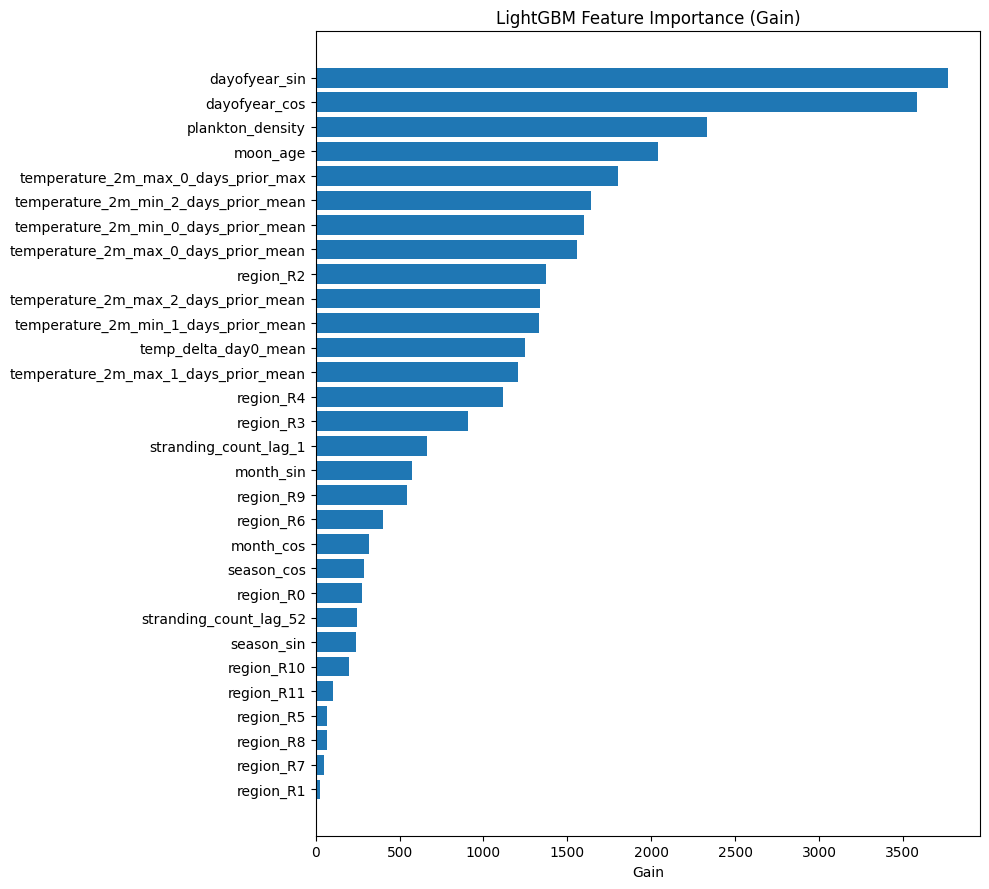

In [6]:
importance = pd.DataFrame(
    {
        "feature": FEATURE_COLS,
        "importance": model.feature_importance(importance_type="gain"),
    }
).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(importance) * 0.3)))
ax.barh(importance["feature"], importance["importance"])
ax.set_title("LightGBM Feature Importance (Gain)")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## SHAP Analysis


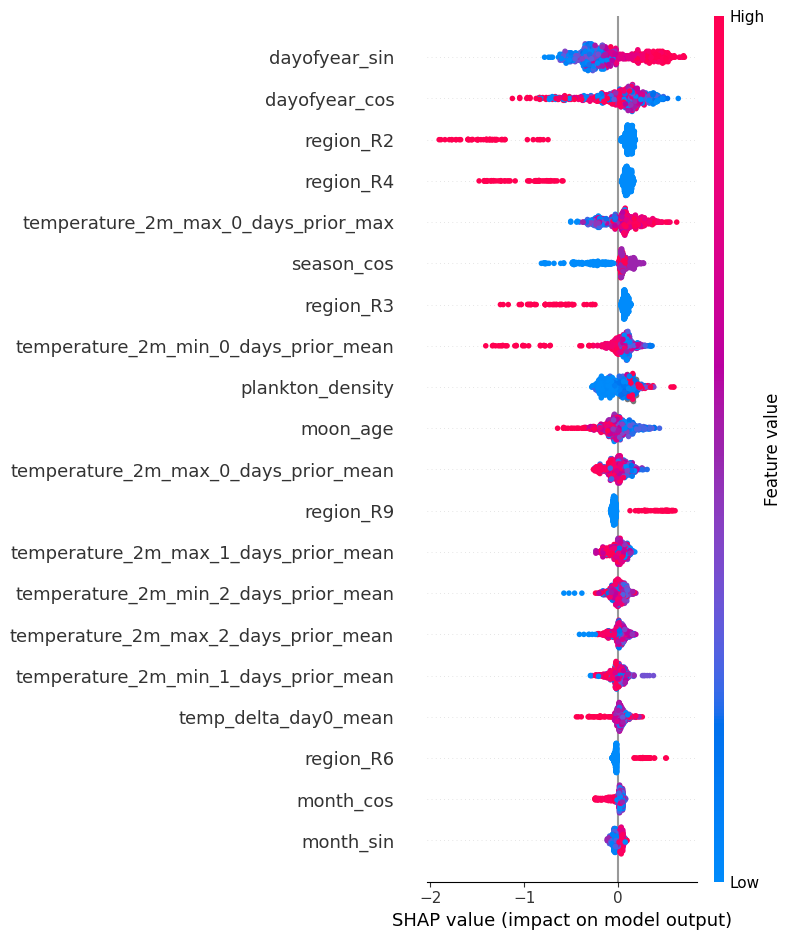

In [7]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(val[FEATURE_COLS])

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, val[FEATURE_COLS], show=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## Save Model and Metrics


In [8]:
# Save model
with open(MODELS_DIR / "lgbm_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save metrics
metrics = {
    "model": "LightGBM (Poisson)",
    "features": FEATURE_COLS,
    "best_iteration": model.best_iteration,
    "params": params,
    "train_mae": float(train_mae),
    "val_mae": float(val_mae),
    "val_rmse": float(val_rmse),
    "val_mean_poisson_deviance": float(val_deviance),
    "baseline_val_mae": float(baseline_val_mae),
    "improvement_pct": float(improvement),
    "train_rows": len(train),
    "val_rows": len(val),
}

with open(PROCESSED_DIR / "full_model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved lgbm_model.pkl and full_model_metrics.json")

Saved lgbm_model.pkl and full_model_metrics.json
